# Tutorial de estruturação populacional - Fst

# Seção 0: Preparação do ambiente do Google Colab
Como feito nos tutoriais anteriores, para que eles funcionem de forma adequada é necessário dar acesso ao Google Drive, onde arquivos e scripts estão localizados, bem como a instalação do Conda e dos pacotes que serão utilizados.

 ❗ **Esses passos são necessários sempre que ocorrer algum período de inatividade ou começo de nova aula prática.**

In [3]:
# Habilitar o acesso ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criação de uma variável para o diretório base
base_dir = "drive/MyDrive/PopGen_UFMG_2026"

Mounted at /content/drive


In [4]:
# Instalar Miniconda (1–2 min)
import os

miniconda_installer = f"{base_dir}/miniconda/Miniconda3-latest-Linux-x86_64.sh"
if not os.path.exists(miniconda_installer):
    !wget -P "{base_dir}/miniconda" https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

!bash "{miniconda_installer}" -bfp /usr/local

# Add conda to the environment
import os
os.environ['PATH'] = '/usr/local/bin:' + os.environ['PATH']

!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

#import numpy
import numpy as np


PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [5]:
# Criação do ambiente Conda e instalação dos programas necessários
!conda create -n diff -c bioconda -c conda-forge -y bcftools vcftools

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - done
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: - \ done

## Package Plan ##

  environment location: /usr/local/envs/diff

  added / updated specs:
    - bcftools
    - vcftools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bcftools-1.23.1            |       hb2cee57_0         927 KB  bioconda
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    gsl-2.7                    |       he838d99_0         3.2 MB  conda-forge
    htslib-1.23.1              |       h633afcb_0         1.1 MB

In [6]:
# Teste do ambiente
!conda run -n diff bcftools --version
!conda run -n diff vcftools --version

bcftools 1.23.1
Using htslib 1.23.1
Copyright (C) 2025 Genome Research Ltd.
License GPLv3+: GNU GPL version 3 or later <http://gnu.org/licenses/gpl.html>
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.
VCFtools (0.1.17)


---
# Seção 1: Diferenciação populacional
Nesse momento do curso, já vimos se existe ou não estrutura entre as populações da nossa espécie-alvo. Entretanto, ainda não avaliamos o quanto elas são diferentes; e, considerando que temos dados genômicos, podemos ainda mensurar essa diferença ao longo dos cromossomos. Como vimos em aula teórica, existem algumas formas de estimar diferenciação entre as populações. Nesse tutorial, vamos estimar **Fst ao longo do genoma**, tanto por sítio quanto em janelas.

❗ **Os comandos abaixo devem ser todos executados em ORDEM, para evitar erros de leitura e perda de etapas intermediárias.**

---
## 1. Dados e softwares
Para estimar Fst, usaremos o mesmo arquivo VCF utilizado na aula de estrutura populacional. Além disso, também vamos precisar do um arquivo com informações (metadados) das amostras utilizadas, visto que aqui faremos **comparações entre populações previamente identificadas e delimitadas**. Os programas que utilizaremos serão o [VCFtools](https://vcftools.github.io/man_latest.html) e o [bcftools](https://samtools.github.io/bcftools/bcftools.html), além de scripts em Python desenvolvidos e utilizados previamente par outros [cursos](https://speciationgenomics.github.io) e [tutoriais](https://github.com/simonhmartin/genomics_general). Os programas já foram instalados acima (na Seção 0), e os scripts necessários estão disponíveis no diretório `scripts/` do drive do curso.

    ✍ Resumindo, para realizar essas análises, são necessários:
        📂 Arquivo VCF
        📂 Arquivo de metadados
        💻 Software VCFtools
        💻 Software bcftools
        💻 Python



In [7]:
# Ler arquivo vcf e metadados
vcf_file = f"{base_dir}/Material/vcf/bradypus_chr_14_15.vcf.gz"
metadata = f"{base_dir}/Material/metadata/metadata.csv"

# Nomes e caminhos dos arquivos de saida
name = "bradypus"
out_dir_win = f"{base_dir}/analyses/07_Fst/janelas"
out_dir_sit = f"{base_dir}/analyses/07_Fst/sitio"

os.makedirs(out_dir_win, exist_ok=True)
os.makedirs(out_dir_sit, exist_ok=True)

geno_file = f"{out_dir_win}/{name}.geno.gz"
north = f"{base_dir}/analyses/07_Fst/North_ids.txt"
south = f"{base_dir}/analyses/07_Fst/South_ids.txt"

---
## 2. Fst por sitio
Aqui, vamos **estimar Weir and Cockerham Fst para cada sítio (SNP)** no nosso conjunto de dados, obtendo o valor por posição genômica e a média. Para isso, vamos utilizar o VCFtools.



#### 2.1) Preparando as populações
Com base na clusterização observada no PCA, que é concordante com a origem geográfica das nossas amostras, vamos separar nossa amostragem em 2 populações de 4-5 indivíduos cada. Para conseguir estimar diferenciação par-a-par, primeiro precisamos criar arquivos com a lista das amostras pertencentes a cada uma das populações. Isso pode ser feito com o script abaixo.

In [8]:
# Criar arquivos para cada populacao baseado no metadata
import pandas as pd
import os

# ler metadata e diretorio
meta = pd.read_csv(metadata)
dir = f"{base_dir}/analyses/07_Fst"

# criar lista
for biome, group in meta.groupby("Biome"):
    ids = group["SampleID"].tolist()
    outfile = os.path.join(dir, f"{biome}_ids.txt")
    with open(outfile, "w") as f:
        for sample_id in ids:
            f.write(sample_id + "\n")
    print(f"{len(ids)} IDs salvos em {outfile}")

5 IDs salvos em drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/North_ids.txt
5 IDs salvos em drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/South_ids.txt


#### 2.2) Estimando Fst
Usaremos finalmente o VCFtools usando de input o arquivo `*.vcf` e listas de duas populações para fazer a estimativa par-a-par.

Abaixo a explicação dos parâmetros usados:

    --gzvcf : input compressed VCF file.
    --out : defines the output filename prefix for all files generated by vcftools.
    --weir-fst-pop : This option is used to calculate an Fst estimate from Weir and Cockerham’s 1984 paper. This is the preferred calculation of Fst. The provided file must contain a list of individuals (one individual per line) from the VCF file that correspond to one population. This option can be used multiple times to calculate Fst for more than two populations. These files will also be included as "--keep" options. By default, calculations are done on a per-site basis. The output file has the suffix ".weir.fst".

In [7]:
# Rodar Fst North x South
!conda run -n diff \
vcftools --gzvcf {vcf_file} --out {out_dir_sit}/north_south \
--weir-fst-pop {north} --weir-fst-pop {south} 2> {out_dir_sit}/north_south.vctools_fst.log

Agora, vamos olhar os arquivos log da análise, onde poderemos ver informações da corrida e o **Fst médio e ponderado**.

In [8]:
# Ver log da analise Norte x Sul
!cat {out_dir_sit}/north_south.vctools_fst.log


VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--gzvcf drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz
	--weir-fst-pop drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/North_ids.txt
	--weir-fst-pop drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/South_ids.txt
	--keep drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/North_ids.txt
	--keep drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/South_ids.txt
	--out drive/MyDrive/PopGen_UFMG_2026/analyses/07_Fst/sitio/north_south

Using zlib version: 1.3.1
Keeping individuals in 'keep' list
After filtering, kept 10 out of 10 Individuals
Outputting Weir and Cockerham Fst estimates.
Weir and Cockerham mean Fst estimate: 0.32694
Weir and Cockerham weighted Fst estimate: 0.66451
After filtering, kept 202116 out of a possible 202116 Sites
Run Time = 27.00 seconds


Vamos também dar uma olhada no conteúdo do output principal da análise, o arquivo `*.weir.fst`, e entender como ele se relaciona com os SNPs obervados nos nossos dados do arquivo `*.vcf`.

In [9]:
# Buscar colunas especificas
!zcat {vcf_file} | grep "#CHROM" -A10| cut -f1,2,4,5,9-19

#CHROM	POS	REF	ALT	FORMAT	BT04	BT05	BT17	BT19	BTPF17	BTPF22	BTPF26	BTPF27	M184BA	M198RJ
manual_scaffold_14	1119	G	A	GT:AD:DP:RGQ:GQ:PL	0/0:11,.:11:33:.:.	0/0:15,.:15:45:.:.	0/0:23,.:23:60:.:.	0/0:20,.:20:57:.:.	0/1:7,10:17:.:99:350,0,179	0/0:23,.:23:69:.:.	0/0:12,.:12:33:.:.	0/0:18,.:18:54:.:.	0/1:13,9:22:.:99:274,0,394	0/0:25,.:25:66:.:.
manual_scaffold_14	2641	G	A	GT:AD:DP:RGQ:GQ:PGT:PID:PL:PS	0/0:27,.:29:30:.:.:.:.:.	0/0:15,.:16:18:.:.:.:.:.	./.:.:.:.:.:.:.:.:.	0|1:16,5:21:.:99:0|1:2641_G_A:143,0,657:2641	0/0:31,.:31:90:.:.:.:.:.	0/0:19,.:19:54:.:.:.:.:.	0/0:14,.:14:39:.:.:.:.:.	0/0:38,.:38:99:.:.:.:.:.	0/0:25,.:26:62:.:.:.:.:.	./.:.:.:.:.:.:.:.:.
manual_scaffold_14	7550	G	T	GT:AD:DP:GQ:PL:RGQ	0/1:26,12:38:99:387,0,912:.	0/0:30,.:30:.:.:90	0/0:42,.:42:.:.:99	0/0:45,.:45:.:.:99	0/0:10,.:10:.:.:27	0/0:13,.:13:.:.:33	./.:.:.:.:.:.	0/0:9,.:9:.:.:24	0/0:9,.:9:.:.:18	./.:.:.:.:.:.
manual_scaffold_14	8121	C	T	GT:AD:DP:RGQ:GQ:PL	0/0:36,.:36:99:.:.	0/0:31,.:31:87:.:.	0/0:42,.:42:99:.:.	./.:.

In [10]:
### Esse script vai resumir os dados para nos mostrar apenas a informacao do genotipo dos individuos
import gzip
vcf = f"{vcf_file}"

max_lines = 10
count = 0

with gzip.open(vcf, "rt") as f:
    for line in f:
        if line.startswith("#CHROM"):
            cols = line.strip().split("\t")
            # selecionar as colunas desejadas
            keep = [0,1,9,10,11,12,13,14,15,16,17,18]
            print("\t".join([cols[i] for i in keep]))
        elif not line.startswith("#"):
            parts = line.strip().split("\t")
            out = [parts[0], parts[1]]  # CHROM, POS
            # mesmas colunas que no cabecalho
            for i in [9,10,11,12,13,14,15,16,17,18]:
                out.append(parts[i].split(":")[0])  # pega so GT
            print("\t".join(out))

            count += 1
            if count >= max_lines:
                break

#CHROM	POS	BT04	BT05	BT17	BT19	BTPF17	BTPF22	BTPF26	BTPF27	M184BA	M198RJ
manual_scaffold_14	1119	0/0	0/0	0/0	0/0	0/1	0/0	0/0	0/0	0/1	0/0
manual_scaffold_14	2641	0/0	0/0	./.	0|1	0/0	0/0	0/0	0/0	0/0	./.
manual_scaffold_14	7550	0/1	0/0	0/0	0/0	0/0	0/0	./.	0/0	0/0	./.
manual_scaffold_14	8121	0/0	0/0	0/0	./.	0/0	0/0	0/1	0/0	0/1	0/0
manual_scaffold_14	8352	0|1	0|1	./.	0|1	0/0	0/0	0/1	0/0	0/1	0|1
manual_scaffold_14	11126	0/0	0/0	0/0	0/0	1/1	1/1	1/1	1/1	1/1	0/0
manual_scaffold_14	11257	0/0	0/0	0/0	0/0	0/0	0/0	0/1	0/0	0/0	0/0
manual_scaffold_14	11645	0/0	0/0	0/0	0/0	0/0	0/1	0/0	0/0	0/0	0/0
manual_scaffold_14	11667	0/0	0/0	0/0	0/0	0/0	0/0	0/0	0/0	0/1	0/0
manual_scaffold_14	11956	0/0	0/0	0/0	0/0	0/0	0/1	0/0	0/0	0/0	0/0


In [12]:
# Lembrando os IDs de cada populacao
!cat {metadata}

SampleID,Biome
BT04,South
BT05,South
BT17,South
BT19,South
M198RJ,South
BTPF17,North
BTPF22,North
BTPF26,North
BTPF27,North
M184BA,North

In [13]:
# Visualizar primeiras linhas do arquivo weir.fst para a comparação Norte x Sul
!head {out_dir_sit}/north_south.weir.fst -n11

CHROM	POS	WEIR_AND_COCKERHAM_FST
manual_scaffold_14	1119	0.125
manual_scaffold_14	2641	0.0989399
manual_scaffold_14	7550	0
manual_scaffold_14	8121	0.0952207
manual_scaffold_14	8352	0.144385
manual_scaffold_14	11126	1
manual_scaffold_14	11257	-1.12757e-16
manual_scaffold_14	11645	-1.12757e-16
manual_scaffold_14	11667	-1.12757e-16
manual_scaffold_14	11956	-1.12757e-16


Observamos, para esse pequeno exemplo, que:
1. quando há alguma variação, mas ela está presente de forma **estatísticamente fraca**, especialmente em função de uma amostragem pequena ou muito desigual, os valores estimados podem ficar negativos como na posição 11257;
2. na **presença de variação**, a ferramenta consegue estimar o Fst.

[Aqui](https://www.biostars.org/p/77372/) tem uma discussão interessante sobre métricas de estimar Fst. Além de estudar em artigos, pode ser de grande ajuda ver discussões em fóruns e em páginas de programas (como issues no github) sobre o uso das ferramentas e o que elas implicam.

#### 2.3) Plot Fst ao longo do genoma
Para plotar o resultado obtido do Fst ao longo do genoma usaremos o script abaixo. Ele recebe de input os caminhos dos arquivos `*.weir.fst` a linha 8, e o nome das comparações feitas (na mesma ordem!) na linha 12. Além disso, ele remove valores inválidos (menor do que 0) antes de fazer o gráfico.

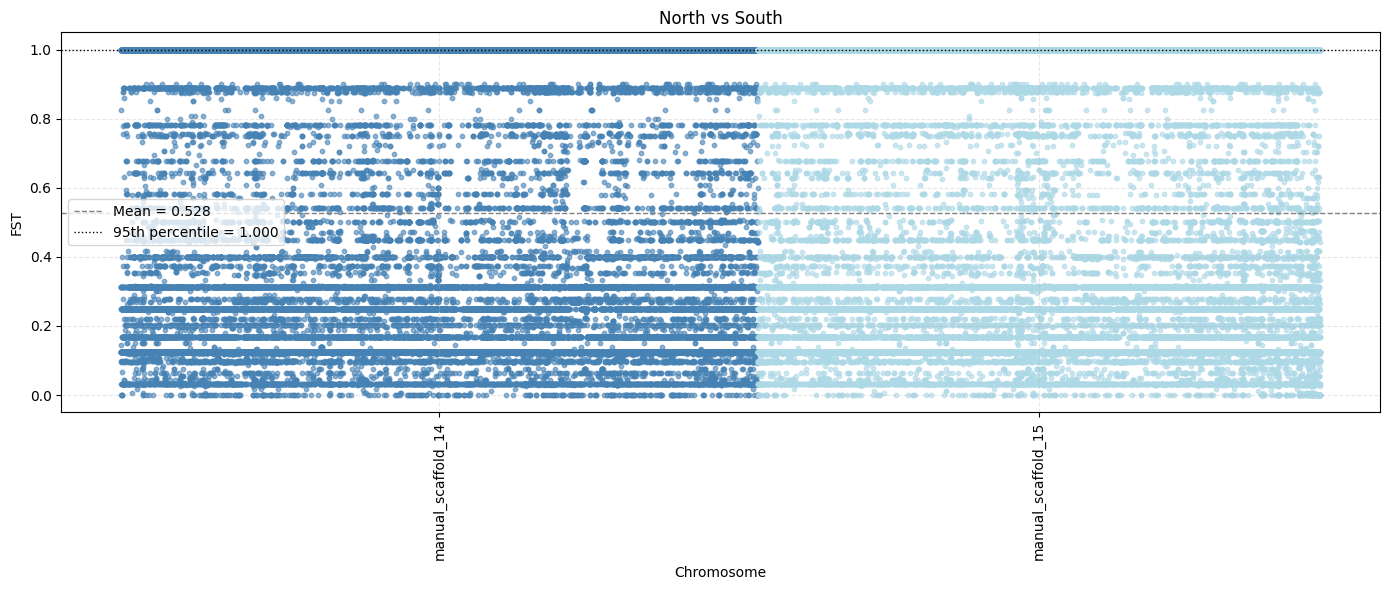

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ler arquivo FST
fst = pd.read_csv(f"{out_dir_sit}/north_south.weir.fst", sep="\t")

# Padronizar nomes das colunas
fst.columns = [col.lower() for col in fst.columns]

fst_cols = [col for col in fst.columns if "fst" in col]
if fst_cols:
    fst.rename(columns={fst_cols[0]: "fst"}, inplace=True)

# Remover valores inválidos
fst = fst.replace([np.inf, -np.inf], np.nan)
fst = fst.dropna(subset=["fst"])
fst = fst[fst["fst"] >= 0]

# Índice contínuo para o eixo X
fst["ind"] = range(len(fst))

# Agrupar por cromossomo
fst_grouped = fst.groupby("chrom")

# Estatísticas globais
fst_mean = fst["fst"].mean()
fst_p95 = fst["fst"].quantile(0.95)

# Plot
plt.figure(figsize=(14, 6))
x_labels = []
x_labels_pos = []

colors = ["steelblue", "lightblue"]

for i, (chrom, group) in enumerate(fst_grouped):
    plt.scatter(group["ind"], group["fst"], color=colors[i % 2], s=10, alpha=0.6)
    x_labels.append(chrom)
    x_labels_pos.append((group["ind"].iloc[0] + group["ind"].iloc[-1]) / 2)

# Linhas de referência
plt.axhline(fst_mean, color="grey", linestyle="--", linewidth=1, label=f"Mean = {fst_mean:.3f}")
plt.axhline(fst_p95, color="black", linestyle=":", linewidth=1, label=f"95th percentile = {fst_p95:.3f}")

# Formatação
plt.xticks(x_labels_pos, x_labels, rotation=90)
plt.xlabel("Chromosome")
plt.ylabel("FST")
plt.title("North vs South")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

> **🦥❓ Questões:**
>
> **a)** Qual o Fst médio e ponderado estimados para as populações de preguiças de coleira do Norte e do Sul?
>
> **b)** Há diferença no Fst entre os cromossomos?
>
> **c)** Como você interpreta essa diferenciação entre as populações?

---
## 3. Fst em janelas
Considerando algumas limitações na estimativa de Fst acima, e em especial na interpretação dos gráficos, uma forma de compensar isso é fazer ao longo janelas (trechos/regiões) de sítios genômicos. Dessa forma, considerando que a flutuação das frequências alélicas tendem a acontecer em blocos ao invés de sítios individuais, e que dessa forma teremos menos pontos no gráfico para plotar, os **padrões de diferenciação ao longo do genoma tendem a ficar mais claros**.

Para isso, usaremos um conjunto de scripts que, utilizando os genótipos dos indivíduos, fará o cálculo das frequências em janelas e irá estimar a diferenciação par-a-par entre as populações.


#### 3.1) Preparando arquivo de genótipos
Para criar o arquivo usaremos o script [parseVCF.py](https://github.com/simonhmartin/genomics_general/tree/master/VCF_processing), previamente desenvolvido por [Simon Martin](https://github.com/simonhmartin) e então adaptado exclusivamente para a realização da nossa prática. Ele usa de arquivo de entrada o nosso `*.vcf.gz` e vai gerar o arquivo `*.geno.gz`.

Abaixo a explicação dos parâmetros usados:

    -i : input VCF file.
    --skipIndels : Skip indels.
    --ploidyMismatchToMissing : Set genotypes with mismatched ploidy to missing.

In [22]:
# Transformar arquivo VCF em tabela de genotipos
!python {base_dir}/Material/scripts/parseVCF.py --skipIndels --ploidyMismatchToMissing -i {vcf_file} | gzip > {geno_file}

In [23]:
# Visualizar tabela
!zcat {geno_file} | head -n15

#CHROM	POS	BT04	BT05	BT17	BT19	BTPF17	BTPF22	BTPF26	BTPF27	M184BA	M198RJ
manual_scaffold_14	1119	G/G	G/G	G/G	G/G	G/A	G/G	G/G	G/G	G/A	G/G
manual_scaffold_14	2641	G/G	G/G	N/N	G|A	G/G	G/G	G/G	G/G	G/G	N/N
manual_scaffold_14	7550	G/T	G/G	G/G	G/G	G/G	G/G	N/N	G/G	G/G	N/N
manual_scaffold_14	8121	C/C	C/C	C/C	N/N	C/C	C/C	C/T	C/C	C/T	C/C
manual_scaffold_14	8352	G|A	G|A	N/N	G|A	G/G	G/G	G/A	G/G	G/A	G|A
manual_scaffold_14	11126	T/T	T/T	T/T	T/T	C/C	C/C	C/C	C/C	C/C	T/T
manual_scaffold_14	11257	G/G	G/G	G/G	G/G	G/G	G/G	G/A	G/G	G/G	G/G
manual_scaffold_14	11645	A/A	A/A	A/A	A/A	A/A	A/G	A/A	A/A	A/A	A/A
manual_scaffold_14	11667	G/G	G/G	G/G	G/G	G/G	G/G	G/G	G/G	G/A	G/G
manual_scaffold_14	11956	C/C	C/C	C/C	C/C	C/C	C/A	C/C	C/C	C/C	C/C
manual_scaffold_14	14141	T/T	T/T	T/T	T/T	C|C	C|C	C|C	C|C	C|C	T/T
manual_scaffold_14	14998	G/G	G/G	G/G	G/G	T/T	T/T	T/T	T/T	T/T	G/G
manual_scaffold_14	15566	C/C	C/C	C/C	C/C	C/C	C/C	C/T	C/T	C/C	C/C
manual_scaffold_14	15856	C/C	C/C	C/C	C/C	C/C	C/C	C/T	C/C	C/T	C/C


#### 3.2) Estimando Fst por janela
Para estimar o Fst por janelas utilizando o arquivo gerado acima utilizaremos o script [popgenWindows.py](https://github.com/simonhmartin/genomics_general/blob/master/popgenWindows.py), também previamente desenvolvido por [Simon Martin](https://github.com/simonhmartin). Esse script, além de gerar Fst em janelas, também faz estimativas de Dxy e Pi. Mas como exercícios relacionados ao curso, vamos focar na análise de Fst.

Abaixo a explicação dos parâmetros usados:

    -g : Input genotypes file.
    -o : Results file.
    -f : Format of genotypes in genotypes file.
    -w : Window size in bases.
    -m : Minumum good sites per window.
    -s : Step size for sliding window.
    -p : Pop name and optionally sample names (separated by commas).
    --popsFile : Optional file of sample names and populations.

In [29]:
# Rodar script de estimativas de diferenciacao por janela entre as populacoes
!python {base_dir}/Material/scripts/popgenWindows.py -g {geno_file} \
-o {out_dir_win}/{name}.Fst.Dxy.pi.csv.gz \
-f phased -w 200000 -m 20 -s 200000 \
-p North -p South \
--popsFile {metadata} 2> {out_dir_win}/{name}.popgenWindows.log

In [30]:
# Visualizar o arquivo de saída
!zcat {out_dir_win}/{name}.Fst.Dxy.pi.csv.gz | head -n5

scaffold,start,end,mid,sites,pi_North,pi_South,dxy_North_South,Fst_North_South
manual_scaffold_14,1,200000,98848,168,0.2368,0.0192,0.4025,0.5303
manual_scaffold_14,200001,400000,311857,150,0.1654,0.0556,0.3703,0.5531
manual_scaffold_14,400001,600000,492817,92,0.1396,0.076,0.413,0.5983
manual_scaffold_14,600001,800000,689048,157,0.1617,0.0617,0.361,0.5402


In [1]:
# Agora vamos visuzalizar melhor as colunas de interesse
!zcat {out_dir_win}/{name}.Fst.Dxy.pi.csv.gz | head -n5 | cut -d "," -f1,4,5,12-14

gzip: {out_dir_win}/{name}.Fst.Dxy.pi.csv.gz: No such file or directory


Algumas coisas que podemos observar:
- As **janelas estão com poucos sítios**, isso provavelmente se deve ao fato de que esse script usa apenas SNPs polimorficos para calcular Fst (o que temos de forma reduzida devido à subamostragem dos dados para o curso)
- Os **valores negativos**, sendo a [fórmula](https://doi.org/10.1093/oxfordjournals.molbev.a040703) de Fst usada aqui `1-(Ks/Kt)`, indicam que `Ks` (média ponderada do número de diferenças dentro de cada população) é maior do que `Kt` (média do número de diferenças geral).

#### 3.3) Plot do Fst por janela
Para plotar o resultado obtido do Fst ao longo de janelas genômicas usaremos o script abaixo. Ele recebe de input apenas o caminho do arquivo `*.Fst.Dxy.pi.csv.gz`, e pega do cabeçalho desse arquivo os nomes das populações e comparações a serem plotadas. Além disso, ele também remove valores inválidos (menor do que 0) antes de fazer o gráfico.

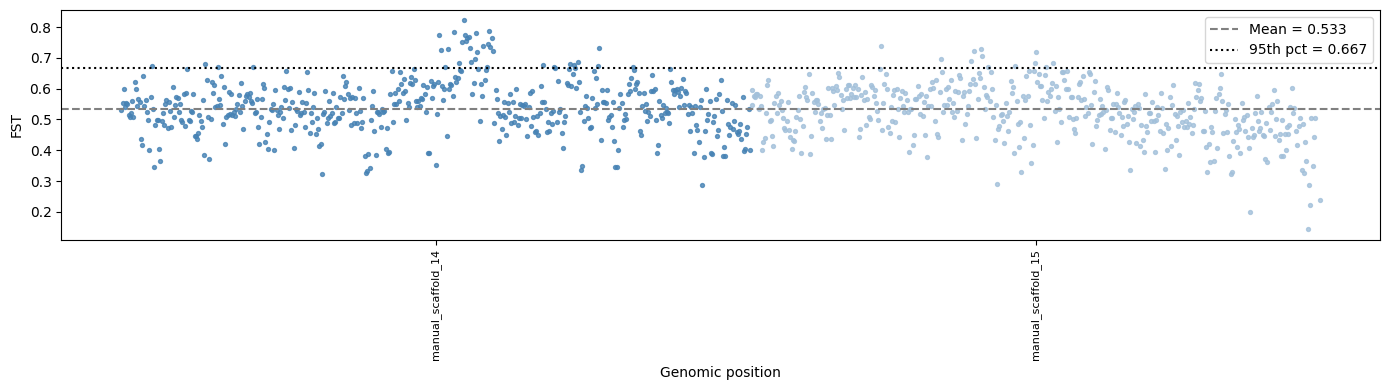

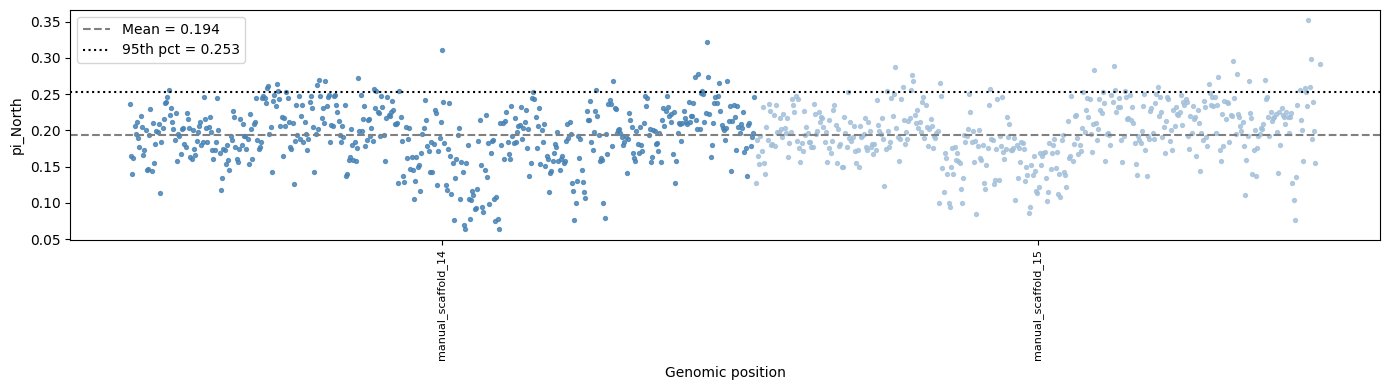

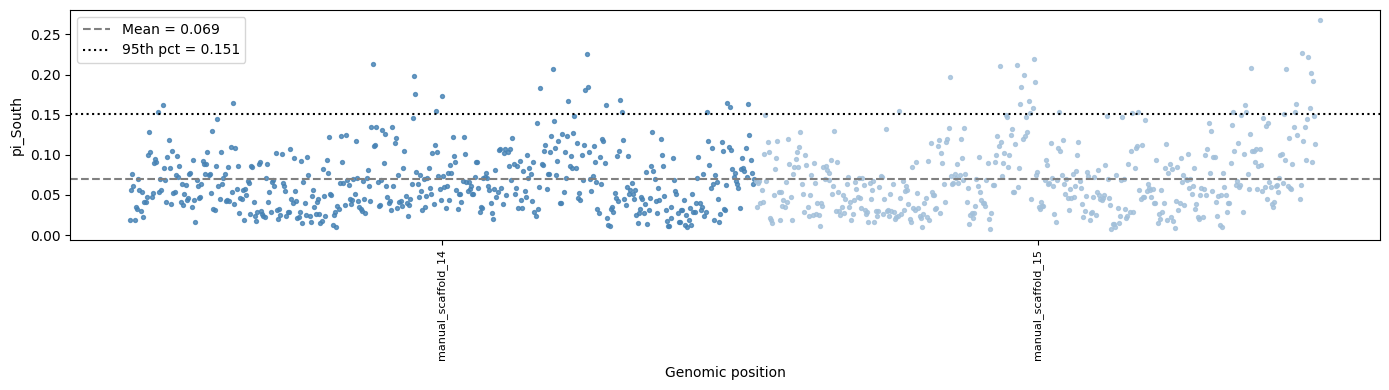

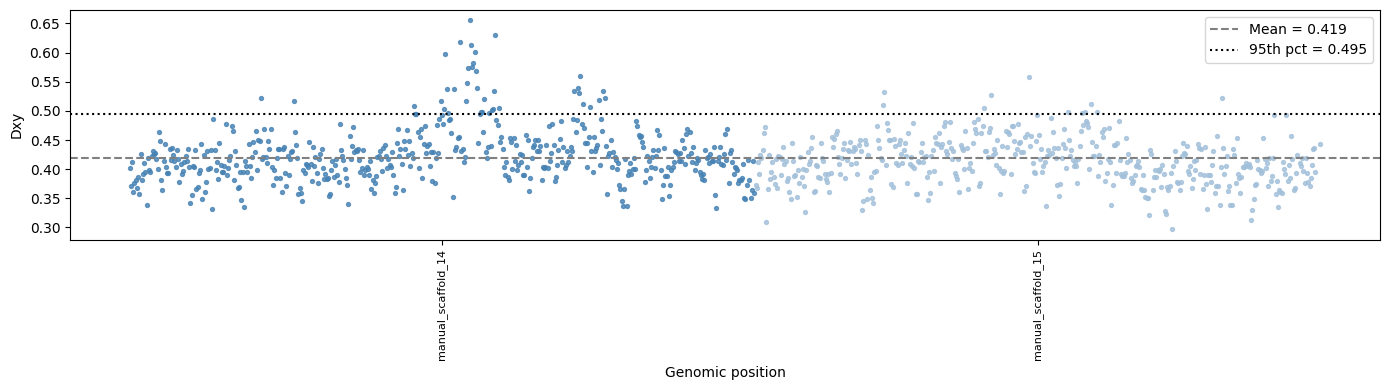

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Ler arquivo
windowStats = pd.read_csv(
    f"{out_dir_win}/{name}.Fst.Dxy.pi.csv.gz"
)

# Remover FST negativos
for col in windowStats.columns:
    if "Fst" in col:
        windowStats.loc[windowStats[col] < 0, col] = np.nan

# Definir posições acumuladas
scaffolds = windowStats["scaffold"].unique()

chrom_sizes = windowStats.groupby("scaffold")["end"].max()

offsets = chrom_sizes.cumsum().shift(fill_value=0)

windowStats["pos_cum"] = windowStats.apply(
    lambda row: row["mid"] + offsets[row["scaffold"]],
    axis=1
)

# Função para clarear cor
def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.hex2color(hex_color)
    white = (1, 1, 1)
    new_rgb = tuple(
        (1 - amount) * c + amount * w
        for c, w in zip(rgb, white)
    )
    return mcolors.to_hex(new_rgb)

# Plot para uma única estatística
def plot_manhattan(df, column, ylabel):

    plt.figure(figsize=(14,4))

    colors = ["steelblue", lighten_color("steelblue", 0.5)]

    for i, scaffold in enumerate(scaffolds):

        sub = df[df["scaffold"] == scaffold]

        plt.scatter(
            sub["pos_cum"],
            sub[column],
            s=8,
            color=colors[i % 2],
            alpha=0.8
        )

    mean_val = df[column].mean(skipna=True)

    pct95 = df[column].quantile(0.95)

    plt.axhline(
        mean_val,
        color="grey",
        linestyle="--",
        label=f"Mean = {mean_val:.3f}"
    )

    plt.axhline(
        pct95,
        color="black",
        linestyle=":",
        label=f"95th pct = {pct95:.3f}"
    )

    chrom_centers = offsets + chrom_sizes / 2

    plt.xticks(
        chrom_centers,
        scaffolds,
        rotation=90,
        fontsize=8
    )

    plt.xlabel("Genomic position")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Identificar colunas
fst_col = [c for c in windowStats.columns if "Fst" in c][0]

pi_cols = [c for c in windowStats.columns if "pi_" in c]

dxy_col = [c for c in windowStats.columns if "dxy_" in c][0]

# Plotar
plot_manhattan(windowStats, fst_col, "FST")

for col in pi_cols:
    plot_manhattan(windowStats, col, col)

plot_manhattan(windowStats, dxy_col, "Dxy")

> **🦥❓ Questões:**
>
> **a)** Qual o tamanho da janela que usamos e quantas janelas válidas tiveram Fst estimado?
>
> **b)** Qual o valor do Fst utilizando a média entre as janelas?

> **c)** Como você interpreta o padrão observado nos plots de Fst obtidos?